# Undulator map

Plot the fields from the Bmad fits of the SXU measured data.

In [1]:
from pytao import Tao
import numpy as np
import matplotlib.pyplot as plt

# Setup and test

In [2]:
tao = Tao('-lat und.bmad -noplot')
ele_id = 'UND_MAP'
attribs = tao.ele_gen_attribs(ele_id)

In [3]:
z = 0.1
field = tao.em_field(1, 0, 0, z, 0)
field

{'B1': 0.0,
 'B2': 0.00293591130047883,
 'B3': 0.0,
 'E1': 0.0,
 'E2': 0.0,
 'E3': 0.0}

# Plot on-axis

In [4]:
zmin = 0
zmax = attribs['L']

zvec = np.linspace(zmin, zmax, 1000);

Text(0, 0.5, '$B_y$ (T)')

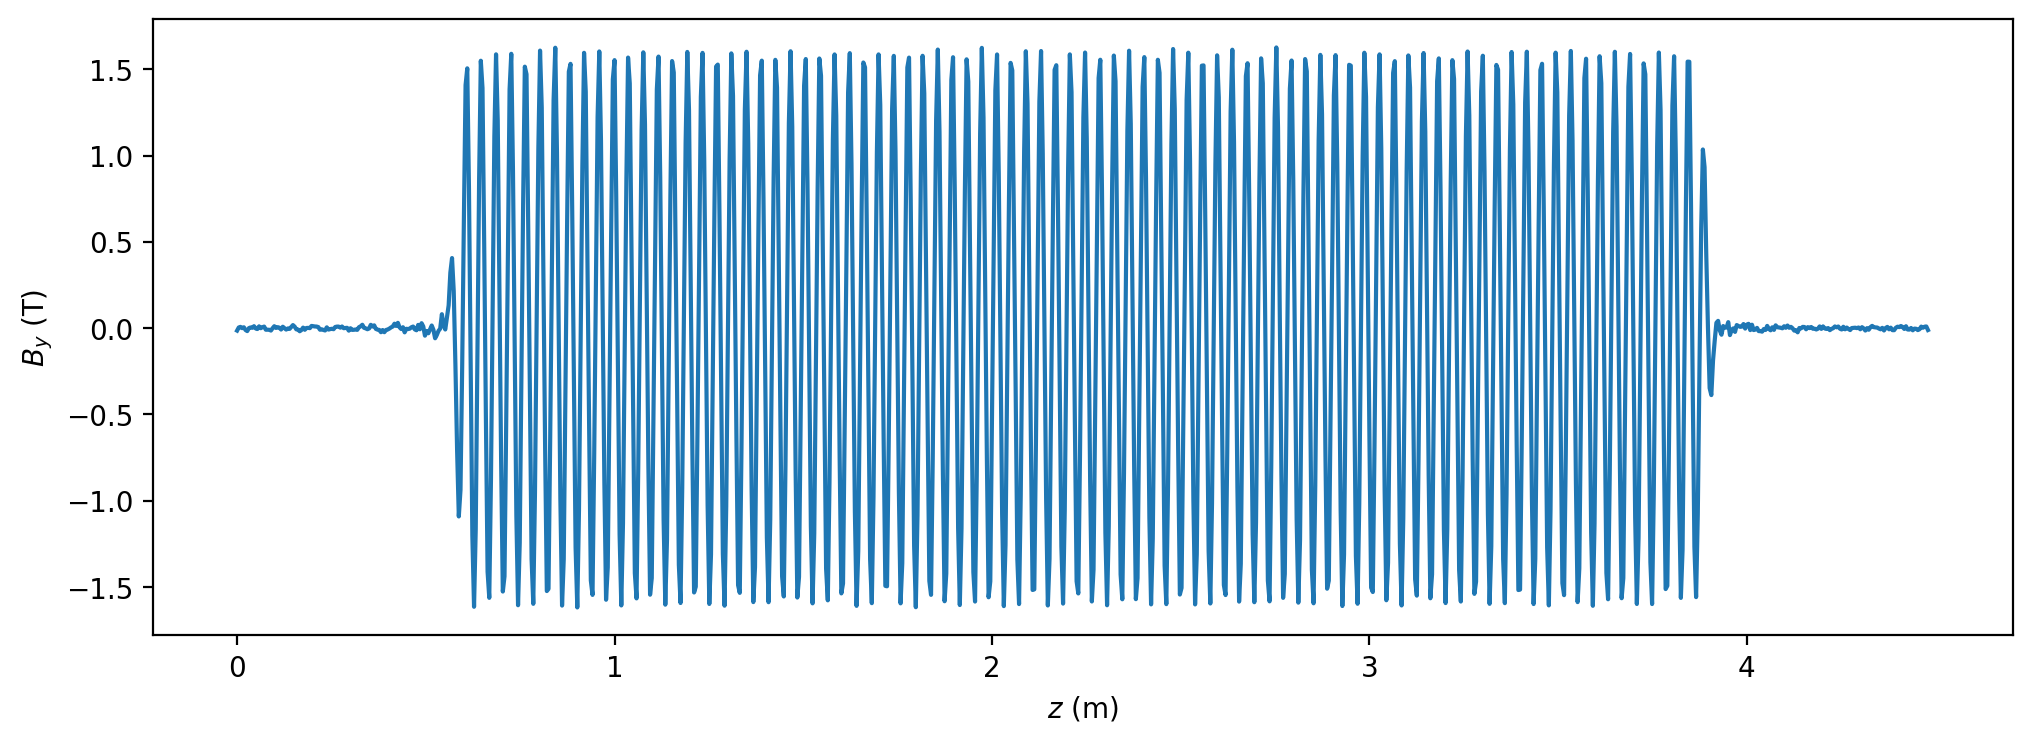

In [5]:
By = np.array([tao.em_field(ele_id, 0, 0, z, 0)['B2'] for z in zvec])

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(zvec, By)
ax.set_xlabel(r'$z$ (m)')
ax.set_ylabel(r'$B_y$ (T)')

# Plot along gap

Notice the artifacts from the expansion.

In [6]:
gap = 7.2e-3

zvec = np.linspace(0, 1, 4*200);

ymax =  gap/ 2
ymin = -ymax
yvec= np.linspace(ymin, ymax, 200);

Z, Y = np.meshgrid(zvec, yvec, indexing='ij')

In [7]:
def get_field(x, y, z, which):
    return tao.em_field(ele_id, x, y, z, 0)[which]

@np.vectorize
def get_By(z, y):
    return get_field(0, y, z, 'B2')
get_By(1, 0)    

array(1.55601264)

In [8]:
BY = get_By(Z, Y)

Text(0, 0.5, '$y$ (mm)')

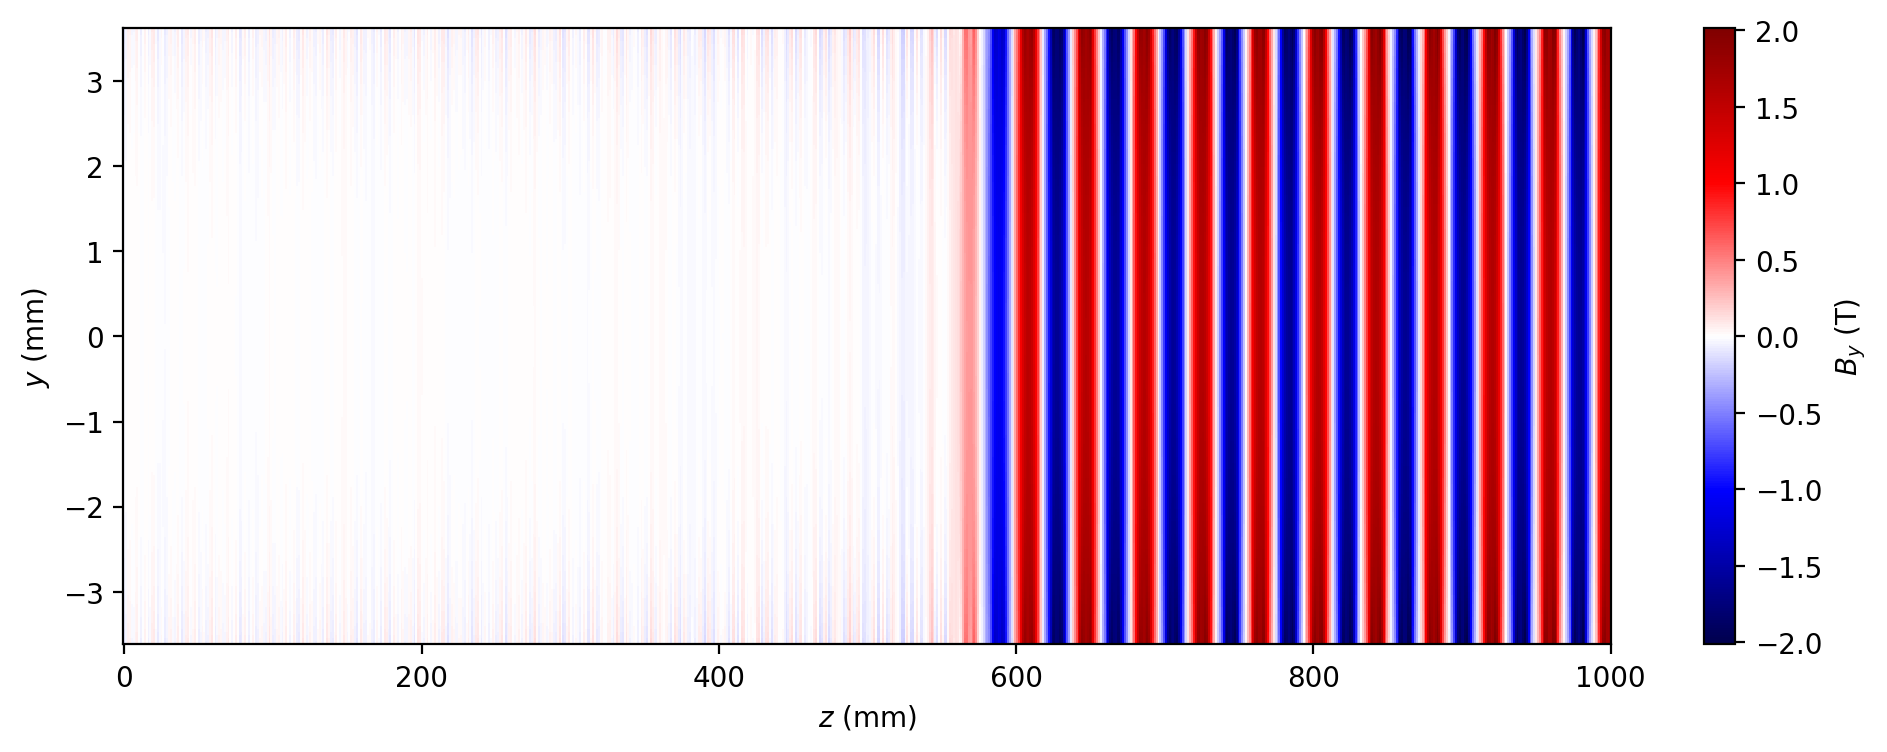

In [9]:
fig, ax = plt.subplots(figsize=(12,4))
c = ax.pcolormesh(Z*1e3, Y*1e3, BY, cmap='seismic')
fig.colorbar(c, ax=ax, label=r'$B_y$ (T)')
ax.set_xlabel(r'$z$ (mm)')
ax.set_ylabel(r'$y$ (mm)')